In [1]:
!pip install -q diffusers transformers accelerate controlnet_aux

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 7.2 MB/s eta 0:00:00


In [2]:
!pip install numpy requests pillow

In [7]:
import torch
import numpy as np
import requests
from io import BytesIO
from PIL import Image, ImageOps
import random
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
import matplotlib.pyplot as plt

# 1. QuickDraw 데이터 로더 & 합성기

QuickDraw의 .npy파일을 직접 다운로드하여 캔버스에 **위치를 지정하여 합성**한다. 단순히 겹치면 그림이 뭉개지므로, 시나리오별로 **Positioning**을 잡아주었다.



In [55]:
# --- 1. QuickDraw 데이터 다운로드 및 합성 함수 ---
def load_quickdraw_category(category):
    # zigzag 데이터셋 이름 처리 (혹시 모를 오류 방지)
    if category == "zigzag":
        url = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/zigzag.npy"
    else:
        url = f"https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/{category}.npy"

    print(f"Downloading data: {category}...")
    try:
        response = requests.get(url)
        response.raise_for_status()
        data = np.load(BytesIO(response.content))
        return data
    except Exception as e:
        print(f"Error downloading {category}: {e}")
        return None


# 2. 시나리오별 데이터 합성 함수

In [60]:
def create_3step_scenario(scenario_name):
    scenarios = {
        "privacy": ["door", "face", "stop sign"],      # 상황 1: 면회 사절
        "pain": ["light bulb", "eye", "zigzag"]        # 상황 2: 눈부심/어지러움 (수정됨)
    }
    # 2. 겹치지 않는 위치 지정 (x, y 좌표)
    # 512x512 캔버스 기준: (좌상단, 우상단, 하단중앙) 등으로 분산
    positions = {
        "privacy": [
            (20, 50),    # Door: 왼쪽
            (280, 50),   # Face: 오른쪽
            (156, 300)   # Stop Sign: 아래쪽
        ],
        "pain": [
            (156, 20),   # Light Bulb: 위쪽 중앙
            (50, 300),   # Eye: 왼쪽 아래
            (280, 300)   # Zigzag: 오른쪽 아래
        ]
    }

    if scenario_name not in scenarios:
        raise ValueError("Unknown scenario. Choose 'privacy' or 'pain'")

    print(f"Creating scenario inputs for: {scenario_name}")
    selected_categories = scenarios[scenario_name]
    current_positions = positions[scenario_name]
    drawings = []

    # 데이터 가져오기 (랜덤 샘플링)
    for cat in selected_categories:
        data = load_quickdraw_category(cat)
        if data is None: return [] # 에러 처리

        random_idx = random.randint(0, len(data) - 1)
        img_array = data[random_idx].reshape(28, 28)
        img = Image.fromarray(img_array).resize((512, 512), resample=Image.BILINEAR)
        img = ImageOps.invert(img) # 흰 배경에 검은 획으로 반전
        drawings.append(img)

    # 3단계 누적 합성
    base_canvas = Image.new("L", (512, 512), 255)
    steps_output = []
    for i, cat in enumerate(selected_categories):
        # 데이터 로드
        data = load_quickdraw_category(cat)
        if data is None: continue

        random_idx = random.randint(0, len(data) - 1)
        img_array = data[random_idx].reshape(28, 28)

        # [핵심 수정 1] 이미지 리사이징 방식 변경 (흐림 방지)
        # BILINEAR 대신 NEAREST를 써야 28px -> 200px로 커져도 선이 진하고 뚜렷하게 남습니다.
        img = Image.fromarray(img_array).resize((200, 200), resample=Image.NEAREST)

        # [핵심 수정 2] 색상 반전 (흰 배경에 검은 선)
        img = ImageOps.invert(img)

        # [핵심 수정 3] 지정된 위치에 붙여넣기 (겹치지 않음)
        x, y = current_positions[i]

        # 투명 배경 처리 (흰색 배경은 투명하게, 검은 선만 복사)
        # img가 이미 반전되었으므로(검은선), 다시 반전시켜 마스크로 씁니다.
        mask = ImageOps.invert(img)
        base_canvas.paste(img, (x, y), mask=mask)

        # 현재 단계 저장
        steps_output.append(base_canvas.copy())

    return steps_output

# 3. ControlNet 모델 설정
steps_output(이미지 3장 리스트)을 받아 ControlNet으로 이미지를 생성한다.

QuickDraw는 Sketch/Scribble에 해당하므로 sd-controlnet-scribble 모델을 선택하였다.

In [9]:
# --- 2. ControlNet 모델 설정 ---
print("Loading ControlNet & Stable Diffusion models... (This may take a while)")
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-scribble", torch_dtype=torch.float16
)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", controlnet=controlnet, torch_dtype=torch.float16
)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.to("cuda")
pipe.enable_model_cpu_offload()

Loading ControlNet & Stable Diffusion models... (This may take a while)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# **4. 생성 실행 함수**

In [69]:
def run_generation(target_scenario):
    input_images = create_3step_scenario(target_scenario)

    prompts = []
    if target_scenario == "privacy":
        prompts = [
            "rough sketch of a door, minimal line art",
            "a door with a face appearing, visitor, sketch style",
            "red stop sign on a door, blocking entry, no visitors symbol, masterpiece, best quality"
        ]
    elif target_scenario == "pain":
        prompts = [
            "light bulb hanging from ceiling, simple sketch",
            "a light bulb and an eye below it, looking up",
            # Zigzag에 맞춘 프롬프트 수정: 어지러움(dizziness), 혼란(confusion) 강조
            "lightning striking an eye, symbol of severe pain, headache, blinding light"
        ]

    generated_images = []
    for i, (img, prompt) in enumerate(zip(input_images, prompts)):
        print(f"Generating Step {i+1} using prompt: '{prompt}'...")
        output = pipe(
            prompt,
            image=img,
            num_inference_steps=30,
            guidance_scale=5.5,
            controlnet_conditioning_scale=0.7
        ).images[0]
        generated_images.append(output)

    return input_images, generated_images

In [65]:
# --- 4. 결과 보기 (시각화) ---
import matplotlib.pyplot as plt

def show_results(inputs, outputs):
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    for i in range(3):
        axs[0, i].imshow(inputs[i], cmap='gray')
        axs[0, i].set_title(f"Input Step {i+1}")
        axs[0, i].axis('off')

        axs[1, i].imshow(outputs[i])
        axs[1, i].set_title(f"Output Step {i+1}")
        axs[1, i].axis('off')
    plt.show()

# show_results(input_imgs, result_imgs)

Creating scenario inputs for: pain
Generating Step 1 using prompt: 'light bulb hanging from ceiling, simple sketch'...


  0%|          | 0/30 [00:00<?, ?it/s]

Generating Step 2 using prompt: 'a light bulb and an eye below it, looking up'...


  0%|          | 0/30 [00:00<?, ?it/s]

Generating Step 3 using prompt: 'lightning striking an eye, symbol of severe pain, headache, blinding light'...


  0%|          | 0/30 [00:00<?, ?it/s]

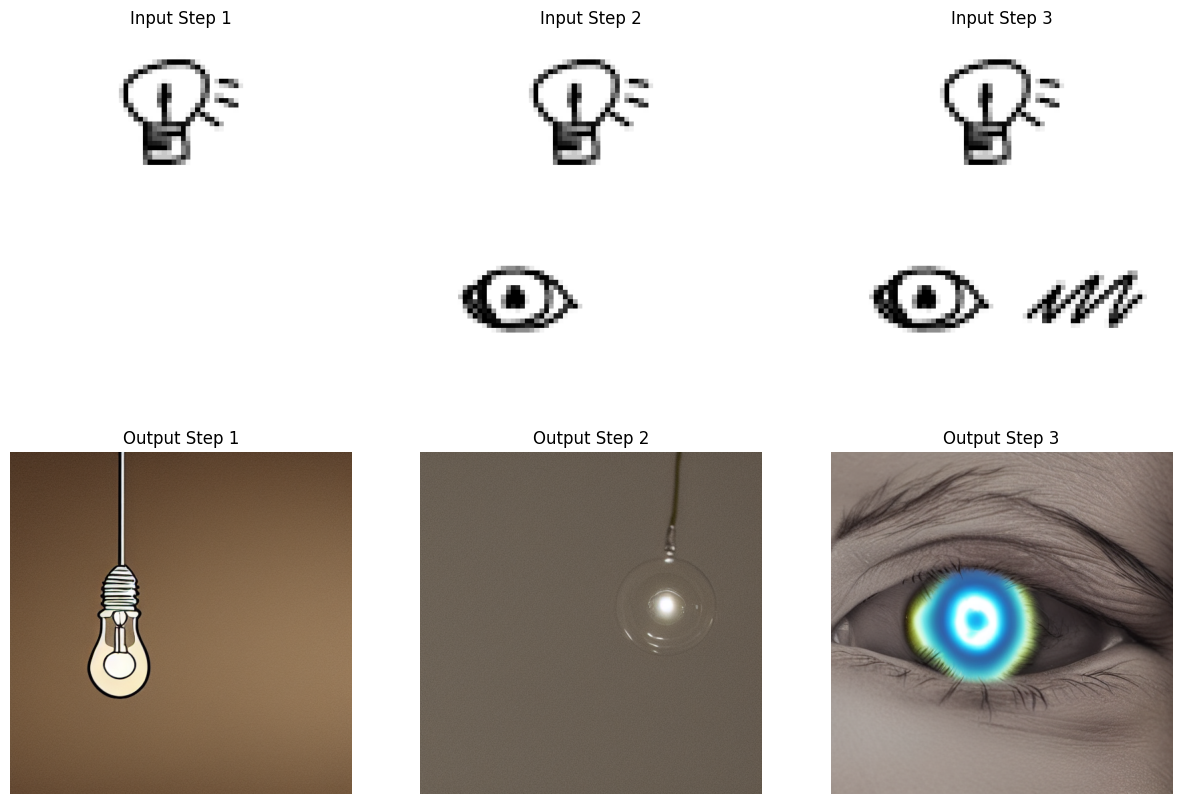

In [70]:
# 'pain' 시나리오 실행
inputs, results = run_generation("pain")
show_results(inputs, results)

Creating scenario: privacy
Generating Step 1...


  0%|          | 0/30 [00:00<?, ?it/s]

Generating Step 2...


  0%|          | 0/30 [00:00<?, ?it/s]

Generating Step 3...


  0%|          | 0/30 [00:00<?, ?it/s]

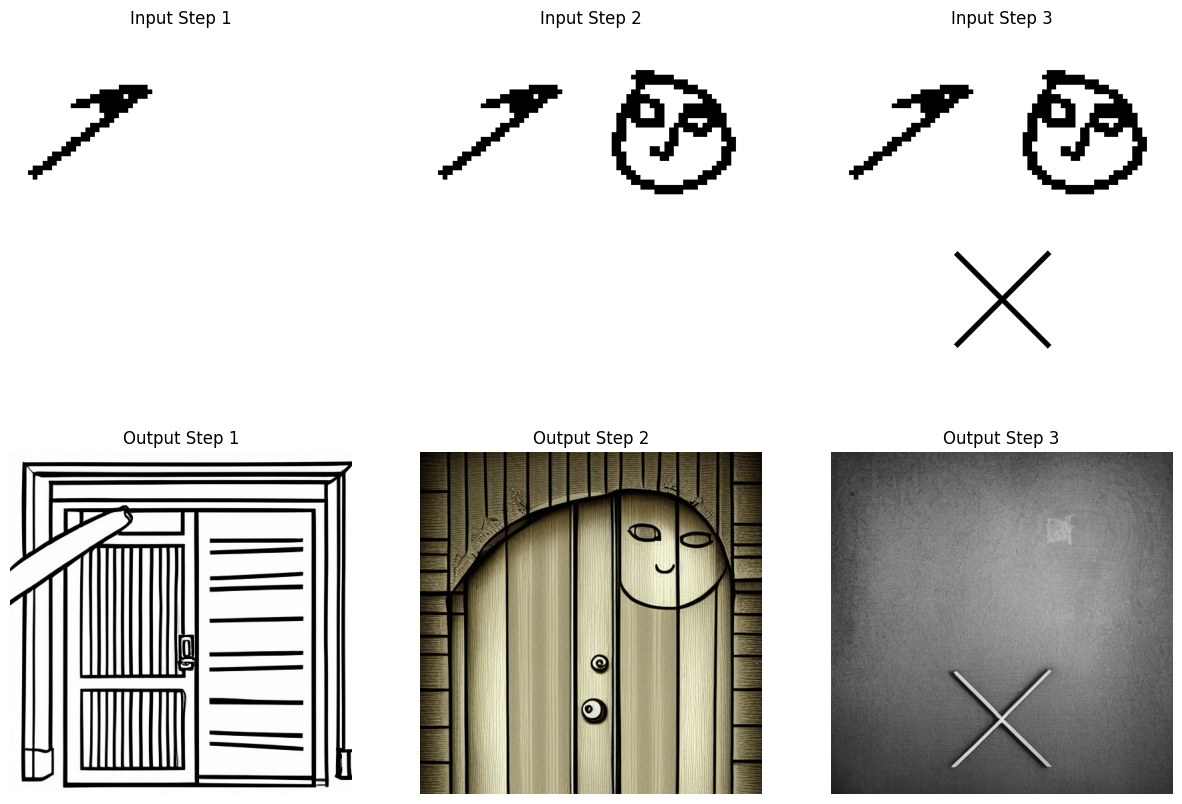

In [46]:
# 'privacy' 시나리오 실행
inputs, results = run_generation("privacy")
show_results(inputs, results)